In [712]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py

In [749]:
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"

In [713]:
snapnum = 40

In [714]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [715]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [716]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

8
<class 'dict'>


In [717]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [797]:
group_sfrs = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


### Central SFR

In [718]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [719]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]

In [720]:
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [325]:
cent_mass = np.zeros(len(mvir))
cent_mass[halos["GroupFirstSub"]>-1] = subhalos["SubhaloMass"][cent_mask_all]*1e10
cent_mass = np.log10(cent_mass)


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [571]:
cent_half_rad = np.zeros(len(mvir))
cent_half_rad[halos["GroupFirstSub"]>-1] = subhalos["SubhaloHalfmassRad"][cent_mask_all]

In [602]:
cent_half_mstar_rad = np.zeros(len(mvir))
cent_half_mstar_rad[halos["GroupFirstSub"]>-1] = subhalos["SubhaloHalfmassRadType"][:,4][cent_mask_all]

### Satellite SFR

In [271]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]
sat_mass = subhalos["SubhaloMass"][~cent_mask_all]*1e10

In [481]:
sat_pos = subhalos["SubhaloPos"][~cent_mask_all]

In [517]:
sat_subflag = subhalos["SubhaloFlag"][~cent_mask_all]

In [289]:
nsat_repeat = np.where(halos["GroupNsubs"] == 0, 0, halos["GroupNsubs"]-1)
mvir_sat = np.repeat(mvir, nsat_repeat)

In [485]:
halo_pos_repeated_x = np.repeat(halos["GroupPos"][:,0], nsat_repeat)
halo_pos_repeated_y = np.repeat(halos["GroupPos"][:,1], nsat_repeat)
halo_pos_repeated_z = np.repeat(halos["GroupPos"][:,2], nsat_repeat)

In [486]:
halo_pos_repeated = np.column_stack((halo_pos_repeated_x,halo_pos_repeated_y,halo_pos_repeated_z))

In [489]:
sat_pos_rel = sat_pos - halo_pos_repeated

In [492]:
sat_pos_rel_mag = np.linalg.norm(sat_pos_rel, axis=1)

In [572]:
cent_half_rad_repeated = np.repeat(cent_half_rad, nsat_repeat)

In [603]:
cent_half_mstar_rad_repeated = np.repeat(cent_half_mstar_rad, nsat_repeat)

In [229]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [19]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [177]:
sum_sfrs = np.zeros(len(mvir))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [230]:
sum_mass1 =  np.add.reduceat(sat_mass, indices)

In [231]:

sum_sat_mass = np.zeros(len(mvir))
sum_sat_mass[unique_ids] = sum_mass1
sum_sat_mass = np.log10(sum_sat_mass)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


In [245]:
sfr_split_array = np.split(sat_sfrs,indices[1:])

In [248]:
msat_split_array = np.split(np.log10(sat_mass), indices[1:])

In [709]:
mask_mass = (mvir >12) & (mvir <12.1) & (sum_sat_mass<11)

In [710]:
stats.spearmanr(sum_sat_mass[mask_mass],sum_sfrs[mask_mass])

SpearmanrResult(correlation=0.5340162046422706, pvalue=4.696473541974725e-224)

Text(0, 0.5, 'log$_{10}$(SFR [M$_\\odot$ yr$^{-1}$])')

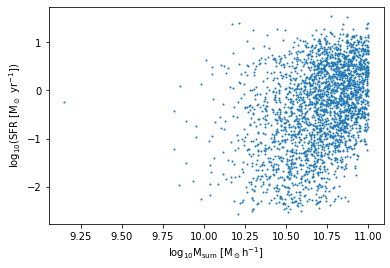

In [711]:
plt.scatter(sum_sat_mass[mask_mass], sum_sfrs[mask_mass], s=1)
plt.xlabel(r"log$_{10}$M$_{\rm sum}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')


Cent vs Sat SFRs

In [737]:
mask_mass = (mvir >11.5) & (mvir <11.6)

In [757]:
logMs = np.arange(10,15, 0.1)
frac_list = []
for logM in logMs:
    mask_mass = (mvir >logM) & (mvir <logM+0.1)
    nonzero = np.sum(sum_sfrs[mask_mass]>cent_sfrs[mask_mass])
    
    tot = np.sum(mask_mass)
    frac = nonzero/tot
    frac_list.append(frac)
print(nonzero)
print(tot)
print(frac)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in long_scalars
  


0
0
nan


Text(0, 0.5, 'Frac of halos with total sat SFR > 0')

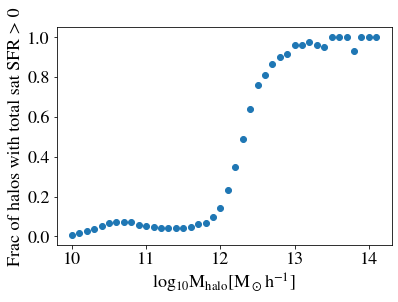

In [758]:
plt.scatter(logMs, frac_list)
plt.xlabel(r"$\rm log_{10} M_{halo} [M_\odot h^{-1}$]")
plt.ylabel("Frac of halos with total sat SFR > 0")

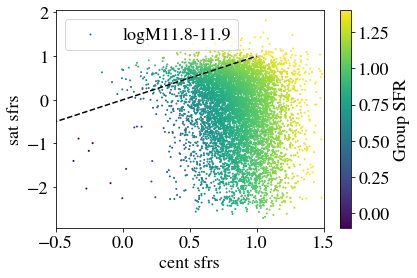

In [869]:
logM=11.8
mask_mass = (mvir >logM) & (mvir <logM+0.1)
plt.scatter(cent_sfrs[mask_mass],sum_sfrs[mask_mass], s=1, label=f"logM{logM}-{logM+0.1:.1f}", c=group_sfrs[mask_mass])
plt.plot([-2,1], [-2,1], c="k", linestyle="dashed")
plt.xlabel("cent sfrs")
plt.ylabel("sat sfrs")
cbar = plt.colorbar()
plt.xlim(-0.5,1.5)
plt.clim(-0.1,1.4)
cbar.ax.set_ylabel("Group SFR")

plt.legend()

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


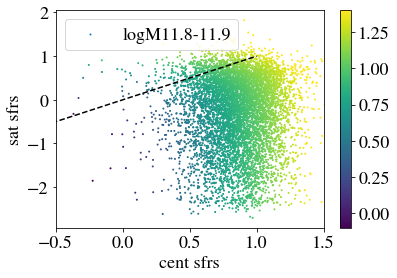

In [870]:
random.seed(0)
s = sum_sfrs[mask_mass]
np.random.shuffle(s)
new_group = np.log10(10**s + 10**cent_sfrs[mask_mass])
plt.scatter(cent_sfrs[mask_mass], s, s=1, label=f"logM{logM}-{logM+0.1:.1f}", c=new_group)
plt.plot([-2,1], [-2,1], c="k", linestyle="dashed")
plt.xlabel("cent sfrs")
plt.ylabel("sat sfrs")
plt.xlim(-0.5,1.5)
cbar = plt.colorbar()
cbar.ax.set_ylabel("Group SFR")
plt.clim(-0.1,1.4)

plt.legend()

Text(0, 0.5, 'Cent SFR')

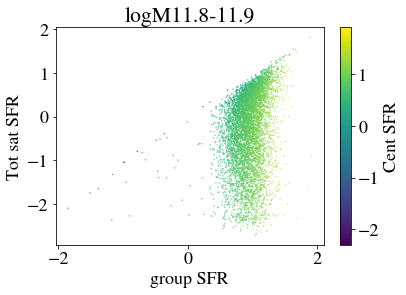

In [871]:
plt.scatter( group_sfrs[mask_mass], sum_sfrs[mask_mass], s=0.1, c=cent_sfrs[mask_mass])
#plt.plot([-2,1], [-2,1], c="k", linestyle="dashed")
plt.title(f"logM{logM}-{logM+0.1:.1f}")
plt.xlabel("group SFR")
plt.ylabel("Tot sat SFR")
cbar = plt.colorbar()
cbar.ax.set_ylabel("Cent SFR")

Text(0, 0.5, 'Cent SFR')

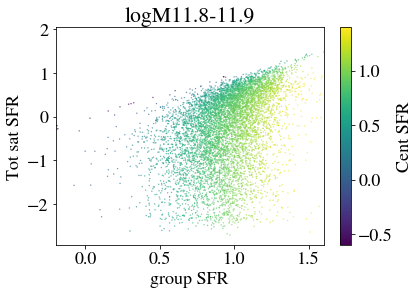

In [872]:

plt.scatter(new_group, s, s=0.1, c=cent_sfrs[mask_mass])
plt.xlim(-0.2,1.6)
plt.title(f"logM{logM}-{logM+0.1:.1f}")
plt.xlabel("group SFR")
plt.ylabel("Tot sat SFR")
cbar = plt.colorbar()
plt.clim(-0.6,1.4)
cbar.ax.set_ylabel("Cent SFR")

Text(0, 0.5, 'Tot sat SFR')

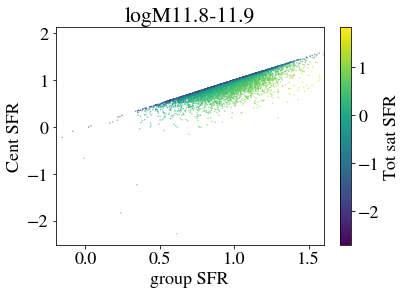

In [873]:
plt.scatter( group_sfrs[mask_mass], cent_sfrs[mask_mass], s=0.1,c=sum_sfrs[mask_mass])
plt.xlim(-0.2,1.6)
plt.title(f"logM{logM}-{logM+0.1:.1f}")
plt.xlabel("group SFR")
plt.ylabel("Cent SFR")
cbar = plt.colorbar()
cbar.ax.set_ylabel("Tot sat SFR")

Text(0, 0.5, 'Tot sat SFR')

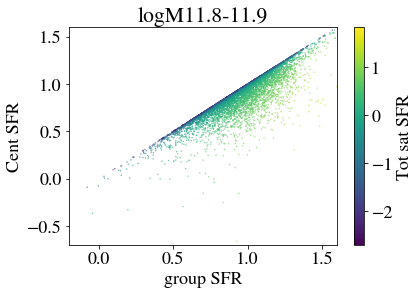

In [874]:
plt.scatter(new_group, cent_sfrs[mask_mass], s=0.1,c=s)
plt.xlim(-0.2,1.6)
plt.ylim(-0.7, 1.6)

plt.title(f"logM{logM}-{logM+0.1:.1f}")
plt.xlabel("group SFR")
plt.ylabel("Cent SFR")
cbar = plt.colorbar()
cbar.ax.set_ylabel("Tot sat SFR")

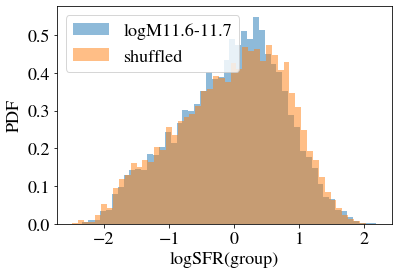

In [820]:
tot_sfrs = cent_sfrs[mask_mass]+ sum_sfrs[mask_mass]
tot_sfrs_shuffled = cent_sfrs[mask_mass] + s
plt.hist(tot_sfrs[tot_sfrs > -5], label=f"logM{logM}-{logM+0.1:.1f}", bins=50, density=True,alpha=0.5)
plt.hist(tot_sfrs_shuffled[tot_sfrs_shuffled > -5], label=f"shuffled", bins=50, density=True, alpha=0.5)
plt.xlabel("logSFR(group)")
plt.ylabel("PDF")
plt.legend()

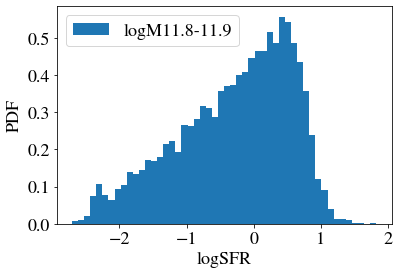

In [780]:
logM=11.8
mask_mass = (mvir >logM) & (mvir <logM+0.1)
plt.hist(sum_sfrs[mask_mass&(sum_sfrs>-5)], bins=50, density=True, label=f"logM{logM}-{logM+0.1:.1f}")
plt.xlabel("logSFR")
plt.ylabel("PDF")
plt.legend()

In [254]:
len(unique_ids)

1116528

In [255]:
len(nsats8)

20332985

In [684]:
mask0 = (sat_sfrs > 0)  & (mvir_sat >13) & (mvir_sat <13.1) & (sat_subflag==True)& (np.log10(sat_pos_rel_mag)<5) #& (sat_pos_rel_mag > 2*cent_half_rad_repeated)#& (mvir_sat < 15)#& (np.log10(sat_mass) > 10.5)


In [497]:
np.sum(sat_sfrs[mask0])

53020.367

In [498]:
np.sum(mask0)

111831

In [639]:
bins=np.arange(8,13,0.1)

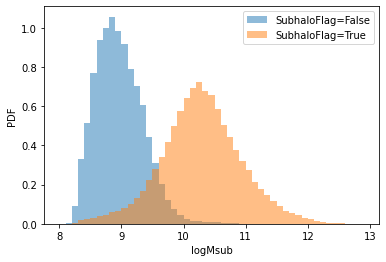

In [652]:
plt.hist(np.log10(sat_mass[mask0 & (sat_subflag==False)]), density=True, bins=bins, label="SubhaloFlag=False", alpha=0.5)
plt.hist(np.log10(sat_mass[mask0 & (sat_subflag==True)]), density=True, bins=bins, label="SubhaloFlag=True", alpha=0.5)
plt.xlabel("logMsub")
plt.ylabel("PDF")
plt.legend()

In [685]:
stats.spearmanr(np.log10(sat_mass[mask0]), np.log10(sat_sfrs[mask0]))

SpearmanrResult(correlation=0.6691989682068958, pvalue=0.0)

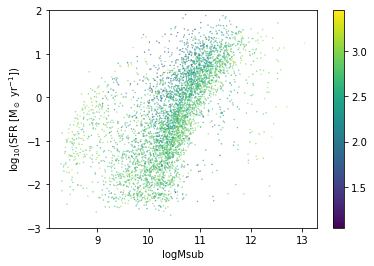

<Figure size 432x288 with 0 Axes>

In [686]:
plt.scatter(np.log10(sat_mass[mask0]), np.log10(sat_sfrs[mask0]), c=np.log10(sat_pos_rel_mag[mask0]), s=0.1)
plt.xlabel("logMsub")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.colorbar()
plt.ylim(-3,2)
plt.show()
plt.clf()

Text(0, 0.5, 'log(Sat distance to centre of halo)')

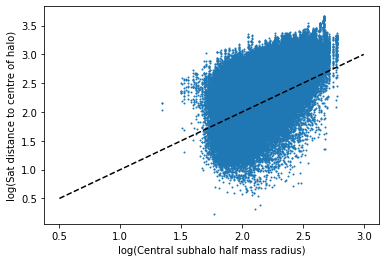

In [610]:
plt.scatter(np.log10(cent_half_rad_repeated[mask0]), np.log10(sat_pos_rel_mag[mask0]), s=1)
plt.plot([0.5,3], [0.5,3], c="k", linestyle="dashed")
plt.xlabel("log(Central subhalo half mass radius)")
plt.ylabel("log(Sat distance to centre of halo)")

Text(0, 0.5, 'logSFR')

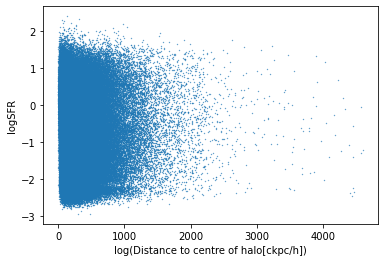

In [599]:
plt.scatter(np.log10(sat_pos_rel_mag[mask0]), np.log10(sat_sfrs[mask0]), s=0.1)
plt.xlabel("log(Distance to centre of halo[ckpc/h])")
plt.ylabel("logSFR")

In [696]:
stats.spearmanr(np.log10(sat_pos_rel_mag[mask0]),np.log10(sat_mass[mask0]))

SpearmanrResult(correlation=-0.10811839558159572, pvalue=1.151529036365731e-12)

In [695]:
stats.spearmanr(np.log10(sat_sfrs[mask0a]),np.log10(sat_mass[mask0a]))

SpearmanrResult(correlation=0.758420717971866, pvalue=6.561987886333693e-91)

In [692]:
mask0a = mask0 & (np.log10(sat_pos_rel_mag) >2.5) & (np.log10(sat_pos_rel_mag) <2.6)

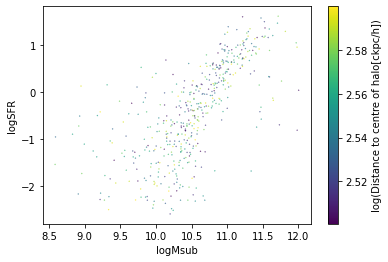

<Figure size 432x288 with 0 Axes>

In [693]:
fig,ax=plt.subplots()
plt.scatter(np.log10(sat_mass[mask0a]), np.log10(sat_sfrs[mask0a]), c=np.log10(sat_pos_rel_mag[mask0a]), s=0.1)
plt.xlabel("logMsub")
plt.ylabel("logSFR")
cbar = plt.colorbar()
cbar.ax.set_ylabel("log(Distance to centre of halo[ckpc/h])")
plt.show()
plt.clf()

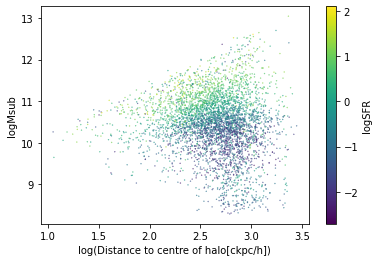

<Figure size 432x288 with 0 Axes>

In [689]:
fig,ax=plt.subplots()
plt.scatter(np.log10(sat_pos_rel_mag[mask0]),np.log10(sat_mass[mask0]), c=np.log10(sat_sfrs[mask0]), s=0.1)
plt.ylabel("logMsub")
plt.xlabel("log(Distance to centre of halo[ckpc/h])")
cbar = plt.colorbar()
cbar.ax.set_ylabel("logSFR")
plt.show()
plt.clf()

In [390]:
mask0_cent = (cent_sfrs < -5) & (mvir > 10)

In [348]:
np.sum(10**cent_sfrs[mask0_cent])

0.0

In [349]:
np.sum(mask0_cent)

885275

Text(0, 0.5, 'PDF')

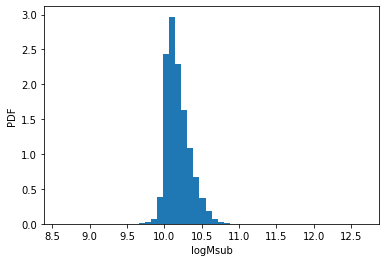

In [350]:
plt.hist(cent_mass[mask0_cent], density=True, bins=50)
plt.xlabel("logMsub")
plt.ylabel("PDF")

In [ ]:
plt.scatter(sat_mass[mask0], sat_sfrs[mask0], s=1)
plt.xlabel(r"log$_{10}$M$_{\rm sub}$ [M$_\odot$h$^{-1}$]")
plt.ylabel("Nsats")
plt.legend()
plt.show()
plt.clf()

In [266]:
nsats01 = []
for i, sfr_arr in enumerate(sfr_split_array):
    mask = sfr_split_array[i] == 0
    nsats01.append(np.sum(mask))

In [267]:
nsats0 = np.zeros(len(mvir))
nsats0[unique_ids] = nsats01

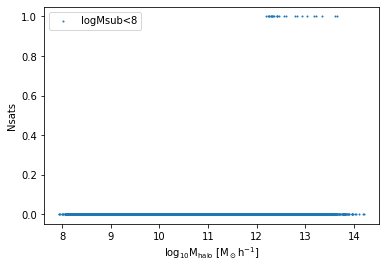

<Figure size 432x288 with 0 Axes>

In [264]:
#plt.scatter(mvir, halos["GroupNsubs"]-1, s=1, label="All")
plt.scatter(sat_mass, nsats0, s=1, label="Msub=0")
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel("Nsats")
plt.legend()
plt.show()
plt.clf()

In [244]:
len(split_array)

1116528

In [24]:
len(unique_ids)

1116528

In [21]:
len(sum_sfrs1)

1116528

I want to compute the number of satellites to get to half the total satellite SFR

First rank order satellite SFRs

In [61]:
import time
start_time = time.time()
sat_sfrs_sorted = np.sort(sat_sfrs)[::-1]
for i, unique_id in enumerate(unique_ids[:1000]):
    mask = sat_ids == unique_id
    sfrs = sat_sfrs_sorted[mask]
    #print(sfrs)
 
    cumsum = np.cumsum(sfrs)
   
    # if len(np.argwhere(cumsum > sum_sfrs1[i]/2)) == 0:
    #     print(i)
        
    if sum_sfrs1[i] == 0:
        nsat = 0
    else:
        index = np.argwhere(cumsum > sum_sfrs1[i]/2)[0]
        nsat = index+1


end_time = time.time()  
time_taken = end_time - start_time
print(time_taken)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [126]:
sat_sfrs_nonzero = sat_sfrs[sat_sfrs > 0]
sat_ids_nonzero = sat_ids[sat_sfrs > 0]

In [157]:
import cProfile

unique_ids1 = unique_ids[sum_sfrs1 > 0]
def find_half():
    # Your code here
    nsats = []
    for i, unique_id in enumerate(unique_ids1):
        mask = sat_ids_nonzero == unique_id
        sfrs = sat_sfrs_nonzero[mask]
        half_index = int(len(sfrs)/2)
        half_sfrs = np.partition(sfrs, half_index)[half_index:]
        #print(half_sfrs)
        half_sfrs.sort()
        sfrs_sorted = half_sfrs[::-1]
        #print(sfrs_sorted)
        cumsum = np.cumsum(sfrs_sorted)



        # if len(np.argwhere(cumsum > sum_sfrs1[i]/2)) == 0:
        #     print(i)

        if sum_sfrs1[i] == 0:
            nsat = 0
        else:
            # index = np.argwhere(cumsum > sum_sfrs1[i]/2)[0]
            # nsat = index+1
            index = np.searchsorted(cumsum, (sum_sfrs1[i]/2))
            nsat = index+1
        nsats.append(nsat)
    
cProfile.run('find_half()')

         6715053 function calls in 80.268 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
   296817    0.179    0.000    1.501    0.000 <__array_function__ internals>:2(cumsum)
   296817    0.247    0.000    1.961    0.000 <__array_function__ internals>:2(partition)
   196049    0.117    0.000    1.025    0.000 <__array_function__ internals>:2(searchsorted)
        1   75.576   75.576   80.253   80.253 <ipython-input-157-60fe6d778f0d>:4(find_half)
        1    0.015    0.015   80.268   80.268 <string>:1(<module>)
   296817    0.109    0.000    0.226    0.000 _asarray.py:86(asanyarray)
   196049    0.027    0.000    0.027    0.000 fromnumeric.py:1272(_searchsorted_dispatcher)
   196049    0.113    0.000    0.653    0.000 fromnumeric.py:1276(searchsorted)
   296817    0.038    0.000    0.038    0.000 fromnumeric.py:2414(_cumsum_dispatcher)
   296817    0.235    0.000    1.153    0.000 fromnumeric.py:2418(cumsum)
   492866    

In [159]:
unique_ids1 = unique_ids[sum_sfrs1 > 0]
nsats = []
for i, unique_id in enumerate(unique_ids1):
    mask = sat_ids_nonzero == unique_id
    sfrs = sat_sfrs_nonzero[mask]
    half_index = int(len(sfrs)/2)
    half_sfrs = np.partition(sfrs, half_index)[half_index:]
    #print(half_sfrs)
    half_sfrs.sort()
    sfrs_sorted = half_sfrs[::-1]
    #print(sfrs_sorted)
    cumsum = np.cumsum(sfrs_sorted)



    # if len(np.argwhere(cumsum > sum_sfrs1[i]/2)) == 0:
    #     print(i)

    if sum_sfrs1[i] == 0:
        nsat = 0
    else:
        # index = np.argwhere(cumsum > sum_sfrs1[i]/2)[0]
        # nsat = index+1
        index = np.searchsorted(cumsum, (sum_sfrs1[i]/2))
        nsat = index+1
    nsats.append(nsat)

In [167]:
nsats_full = np.zeros(len(mvir))
nsats_full[unique_ids1] = nsats

Text(0, 0.5, 'Nsats(for half SFR)')

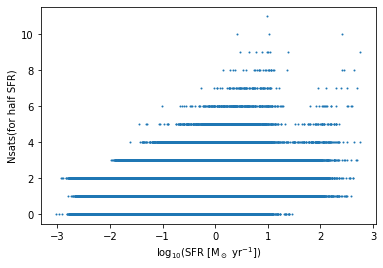

In [163]:
plt.scatter(np.log10(sum_sfrs1[sum_sfrs1 > 0]), nsats, s=1)
plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylabel("Nsats(for half SFR)")

In [232]:
mask1 = (mvir>11.5) & (mvir<11.6) & (sum_sfrs>-5) & (cent_sfrs>-5) & (np.array(c200c) > 0)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in true_divide
  """Entry point for launching an IPython kernel.


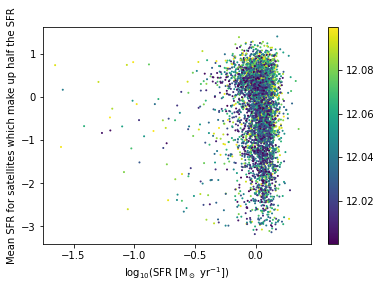

In [203]:
plt.scatter(cent_sfrs[mask1], np.log10((10**sum_sfrs[mask1]/2)/nsats_full[mask1]), c=mvir[mask1], s=1)
plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylabel("Mean SFR for satellites which make up half the SFR")
plt.colorbar()

In [204]:
from scipy import stats
stats.pearsonr(cent_sfrs[mask1], np.log10((10**sum_sfrs[mask1]/2)/nsats_full[mask1]))


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in true_divide
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/scipy/stats/stats.py:3862: RuntimeWarning: invalid value encountered in subtract
  ym = y.astype(dtype) - ymean


ValueError: array must not contain infs or NaNs

Correlation with concentration

In [205]:
halo_path = f"{basePath}/postprocessing/halo_structure"
fname_halo = f"{halo_path}/halo_structure_0{snapnum}.hdf5"
f = h5py.File(fname_halo, 'r')

In [206]:
c200c = f["c200c"]

In [233]:
stats.pearsonr(c200c[mask1], halos["GroupNsubs"][mask1])


(-0.1243776511418667, 5.628139288851258e-35)

Text(0.5, 0, 'Nsubs')

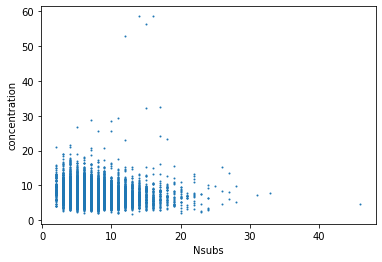

In [234]:
plt.scatter(halos["GroupNsubs"][mask1], c200c[mask1], s=1)
plt.ylabel("concentration")
plt.xlabel("Nsubs")